In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    RandomForestRegressor,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sns.set()

# Métodos de ensamble
## Ensambles en clasificación y comparativa final
**Aprendizaje de Máquina - CEIA - FIUBA**

En las notebooks 2 y 3 desarrollamos bagging, random forest y boosting sobre un problema
de **regresión** (Hitters). Todo lo que vimos —el bootstrap, la decorrelación por
`max_features`, el aprendizaje secuencial sobre los errores, el early stopping— vale
igual para **clasificación**, con dos diferencias:

- En lugar de **promediar** las predicciones, se **votan** (o se promedian las
  probabilidades, como en la notebook 1).
- En lugar de ajustar residuos numéricos, el boosting trabaja sobre el gradiente de una
  pérdida de clasificación (log-loss).

Esta notebook cierra la clase con dos objetivos:

1. Aplicar bagging, random forest y boosting a **clasificación**, sobre Pima.
2. Reunir **todos** los modelos en una única
   comparativa contra la heurística de referencia.

Usamos **Pima Indians Diabetes** con el mismo split de siempre, así que todo es
directamente comparable.

In [2]:
df_pima = pd.read_csv("datasets/pima_diabetes.csv")

X = df_pima.drop(columns='diabetes')
y = df_pima['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
    random_state=0, stratify=y)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} muestras | Testeo: {X_test.shape[0]}")
print(f"Balance de clases: {dict(y.value_counts())}")

Entrenamiento: 576 muestras | Testeo: 192
Balance de clases: {0: np.int64(500), 1: np.int64(268)}


Reutilizamos las mismas funciones de la notebook 1. Recordemos la metodología: el
**umbral de decisión es un hiper-parámetro** y se elige por validación cruzada sobre el
entrenamiento, nunca mirando el testeo.

In [3]:
def buscar_umbral(modelo):
    """Busca el umbral que maximiza el F1 por CV sobre el ENTRENAMIENTO."""
    proba_oof = cross_val_predict(modelo, X_train, y_train, cv=CV,
                                  method='predict_proba', n_jobs=-1)[:, 1]
    umbrales = np.linspace(0.05, 0.95, 181)
    f1s = np.array([f1_score(y_train, (proba_oof >= u).astype(int))
                    for u in umbrales])
    return umbrales[f1s.argmax()], f1s.max()


def evaluar(nombre, modelo):
    """Ajusta el umbral por CV, entrena y evalúa sobre el testeo."""
    umbral, f1_cv = buscar_umbral(modelo)

    modelo.fit(X_train, y_train)
    proba = modelo.predict_proba(X_test)[:, 1]
    y_pred = (proba >= umbral).astype(int)

    return {
        "modelo": nombre,
        "Umbral": umbral,
        "F1 (CV train)": f1_cv,
        "F1 (test)": f1_score(y_test, y_pred),
        "Exac. balanceada": balanced_accuracy_score(y_test, y_pred),
        "Precisión": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, proba),
    }

---
## Bagging de árboles de clasificación

Empezamos igual que en la notebook 2: muchos árboles sin podar, cada uno sobre un
remuestreo bootstrap, pero ahora votando en lugar de promediar. La clase es
[`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html).

Como las clases están desbalanceadas (65% / 35%), le pasamos `class_weight='balanced'`
al árbol base, igual que veníamos haciendo.

In [4]:
arbol_c4 = DecisionTreeClassifier(criterion='gini', max_depth=4,
                                  min_samples_split=16, min_samples_leaf=13,
                                  class_weight='balanced', random_state=42)

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    n_estimators=300, oob_score=True, random_state=42, n_jobs=-1)

metricas = [
    evaluar("Árbol", arbol_c4),
    evaluar("Bagging de árboles", bagging),
]
pd.DataFrame(metricas).set_index("modelo").round(4)

,Umbral,F1 (CV train),F1 (test),Exac. balanceada,Precisión,Recall,AUC
modelo,,,,,,,
Árbol,0.455,0.6681,0.6957,0.7659,0.5957,0.8358,0.8294
Bagging de árboles,0.315,0.6879,0.7143,0.7824,0.6322,0.8209,0.8482


In [5]:
bagging.fit(X_train, y_train)
print(f"Exactitud out-of-bag: {bagging.oob_score_:.4f}")

Exactitud out-of-bag: 0.7378


El bagging mejora al árbol individual en F1 de validación cruzada, tal como
esperábamos, y de nuevo obtenemos la estimación **out-of-bag** gratis.

---
## Random Forest

Acá aparece un detalle que vale la pena remarcar, porque **contradice lo que vimos en la
notebook 2**.

Allá descubrimos que `RandomForestRegressor` viene con `max_features=1.0` por defecto,
o sea que un random forest de regresión sin configurar **es** un bagging.

En clasificación **no pasa lo mismo**: `RandomForestClassifier` usa `max_features='sqrt'`
por defecto, es decir $\sqrt{p}$ atributos por división. Comprobémoslo, y de paso
barramos el parámetro como hicimos en regresión.

In [6]:
print("Defecto en RandomForestClassifier :",
      RandomForestClassifier().max_features)
print("Defecto en RandomForestRegressor  :",
      RandomForestRegressor().max_features)
print(f"\nAtributos totales: {X.shape[1]} -> sqrt = "
      f"{int(np.sqrt(X.shape[1]))} atributos por división")

Defecto en RandomForestClassifier : sqrt
Defecto en RandomForestRegressor  : 1.0

Atributos totales: 8 -> sqrt = 2 atributos por división


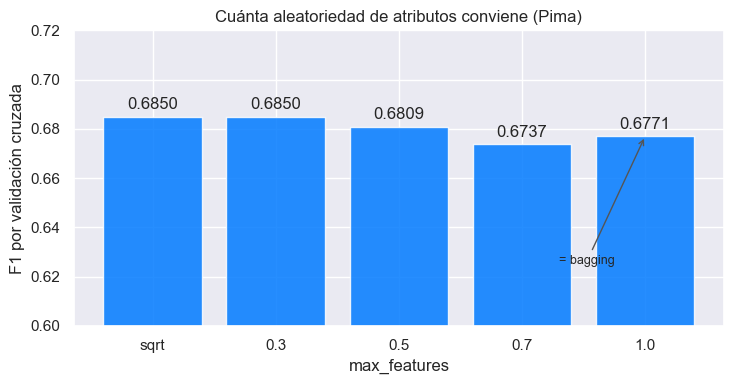

In [7]:
opciones = ['sqrt', 0.3, 0.5, 0.7, 1.0]
filas_mf = []

for mf in opciones:
    modelo = RandomForestClassifier(n_estimators=500, max_features=mf,
                                    class_weight='balanced', random_state=42,
                                    n_jobs=-1)
    _, f1_cv = buscar_umbral(modelo)
    filas_mf.append({"max_features": str(mf), "F1 (CV train)": f1_cv})

df_mf = pd.DataFrame(filas_mf).set_index("max_features")

fig, ax = plt.subplots(figsize=(7.5, 4))
barras = ax.bar(df_mf.index, df_mf["F1 (CV train)"], color="#007aff", alpha=0.85)
ax.bar_label(barras, fmt="%.4f", padding=3)
ax.set_ylim(0.6, 0.72)
ax.set_ylabel("F1 por validación cruzada")
ax.set_xlabel("max_features")
ax.set_title("Cuánta aleatoriedad de atributos conviene (Pima)")
ax.annotate("= bagging", xy=(4, df_mf.loc["1.0", "F1 (CV train)"]),
            xytext=(3.3, 0.625), fontsize=9,
            arrowprops={"arrowstyle": "->", "color": "#555555"})
plt.tight_layout()
plt.show()

Se repite el patrón de la notebook 2: restringir los atributos ayuda, y
`max_features=1.0` (o sea, bagging puro) es la peor opción. El valor por defecto
`'sqrt'` resulta ser el mejor, lo cual explica por qué en clasificación casi nunca hace
falta tocarlo.

Entrenamos el Random Forest final.

In [8]:
rf = RandomForestClassifier(n_estimators=500, max_features='sqrt',
                            class_weight='balanced', oob_score=True,
                            random_state=42, n_jobs=-1)

metricas.append(evaluar("Random Forest", rf))
pd.DataFrame(metricas).set_index("modelo").round(4)

,Umbral,F1 (CV train),F1 (test),Exac. balanceada,Precisión,Recall,AUC
modelo,,,,,,,
Árbol,0.455,0.6681,0.6957,0.7659,0.5957,0.8358,0.8294
Bagging de árboles,0.315,0.6879,0.7143,0.7824,0.6322,0.8209,0.8482
Random Forest,0.325,0.6850,0.7333,0.7984,0.6627,0.8209,0.8475


---
## Boosting en clasificación

Pasamos a la familia secuencial. Probamos las tres implementaciones:

- **AdaBoost** con tocones (`max_depth=1`), que es su uso clásico en clasificación.
- **Gradient Boosting** de Scikit-Learn.
- **XGBoost**, que para clasificación desbalanceada ofrece `scale_pos_weight`: el
  análogo de `class_weight='balanced'`, y se fija como la razón entre muestras negativas
  y positivas.

In [9]:
razon = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = negativos / positivos = {razon:.3f}")

ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                         n_estimators=300, learning_rate=0.5, random_state=42)

gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                max_depth=3, random_state=42)

xgb_default = xgb.XGBClassifier(random_state=42, n_jobs=-1)

xgb_tuned = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=42, n_jobs=-1)

xgb_spw = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3,
                            subsample=0.8, colsample_bytree=0.8,
                            scale_pos_weight=razon, random_state=42, n_jobs=-1)

metricas += [
    evaluar("AdaBoost", ada),
    evaluar("Gradient Boosting", gb),
    evaluar("XGBoost (por defecto)", xgb_default),
    evaluar("XGBoost (regularizado)", xgb_tuned),
    evaluar("XGBoost (scale_pos_weight)", xgb_spw),
]
pd.DataFrame(metricas).set_index("modelo").round(4)

scale_pos_weight = negativos / positivos = 1.866


,Umbral,F1 (CV train),F1 (test),Exac. balanceada,Precisión,Recall,AUC
modelo,,,,,,,
Árbol,0.455,0.6681,0.6957,0.7659,0.5957,0.8358,0.8294
Bagging de árboles,0.315,0.6879,0.7143,0.7824,0.6322,0.8209,0.8482
Random Forest,0.325,0.6850,0.7333,0.7984,0.6627,0.8209,0.8475
AdaBoost,0.470,0.6865,0.7083,0.7766,0.6623,0.7612,0.8570
Gradient Boosting,0.315,0.6696,0.7190,0.7864,0.6395,0.8209,0.8487
XGBoost (por defecto),0.140,0.6555,0.6883,0.7595,0.6092,0.7910,0.8328
XGBoost (regularizado),0.390,0.6698,0.7050,0.7737,0.6806,0.7313,0.8473
XGBoost (scale_pos_weight),0.285,0.6680,0.6951,0.7654,0.5876,0.8507,0.8427


Dos cosas para destacar:

- **XGBoost con los valores por defecto es el peor de los ensambles.** Con 576 muestras
  de entrenamiento, `learning_rate=0.3` y `max_depth=6` sobreajustan. Bajando el
  learning rate y agregando submuestreo mejora bastante, pero aun así **no alcanza al
  Random Forest**. Es la misma conclusión de la notebook 3, ahora en clasificación:
  el boosting moderno necesita volumen de datos para desplegar su ventaja, y 768 filas
  siguen siendo pocas.
- **`scale_pos_weight` no aporta acá**, porque ya estamos ajustando el **umbral** por
  validación cruzada, y ambos mecanismos hacen esencialmente lo mismo: correr la
  frontera hacia la clase minoritaria. Aplicar los dos a la vez es redundante. Si uno
  ajusta el umbral, normalmente no necesita repesar las clases (y viceversa).

---
## ¿Qué mira el bosque? La heurística, revisitada

Cerramos con algo lindo. Desde el principio venimos usando como baseline una regla
heurística sacada del EDA: **"si la glucosa supera 123.5, predecir diabetes"**.

Ahora que tenemos un Random Forest de 500 árboles, podemos preguntarle qué variables usa
y ver si le da la razón a esa intuición.

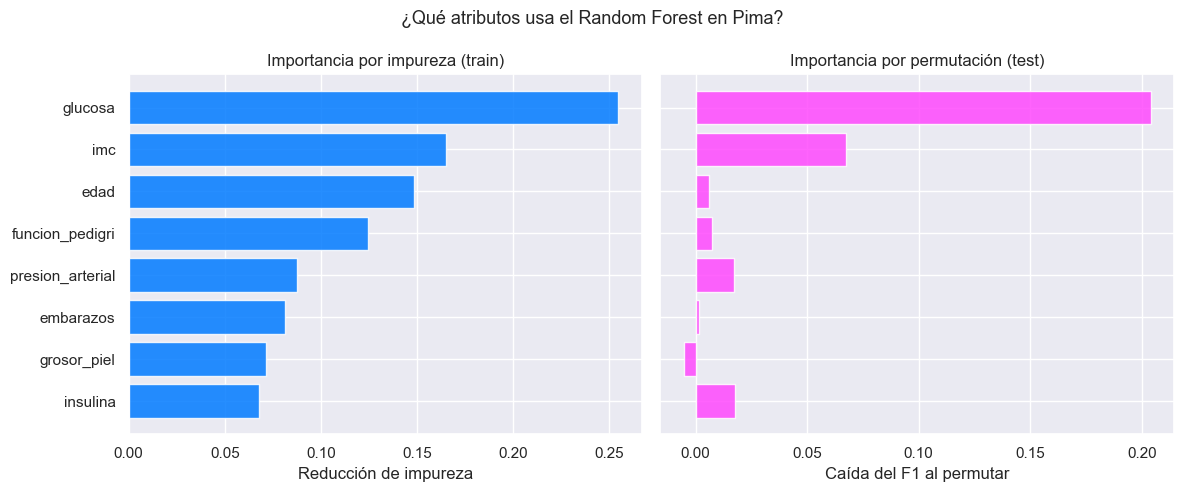

In [10]:
rf.fit(X_train, y_train)

imp_impureza = pd.Series(rf.feature_importances_, index=X.columns)

perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42,
                              n_jobs=-1, scoring='f1')
imp_perm = pd.Series(perm.importances_mean, index=X.columns)

orden = imp_impureza.sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].barh(orden, imp_impureza[orden], color="#007aff", alpha=0.85)
axes[0].set_xlabel("Reducción de impureza")
axes[0].set_title("Importancia por impureza (train)")

axes[1].barh(orden, imp_perm[orden], color="#ff48fd", alpha=0.85)
axes[1].set_xlabel("Caída del F1 al permutar")
axes[1].set_title("Importancia por permutación (test)")

plt.suptitle("¿Qué atributos usa el Random Forest en Pima?", fontsize=13)
plt.tight_layout()
plt.show()

**`glucosa` domina ampliamente por los dos criterios** —con aproximadamente el
triple de importancia que la siguiente— y `imc` queda segunda también en ambos.

O sea: un ensamble de 500 árboles, con toda su maquinaria, termina apoyándose
principalmente en la misma variable que habíamos identificado a ojo en el EDA. Eso explica de una vez por qué el baseline de glucosa venía siendo tan difícil
de superar, y es un buen argumento a favor de hacer siempre un EDA serio antes de
modelar: la heurística simple ya estaba capturando el grueso de la señal.

Más abajo los dos criterios discrepan: `edad` y `funcion_pedigri` aparecen 3ª y 4ª por
impureza pero caen al fondo por permutación. Es el sesgo que discutimos en la notebook 2:
son variables continuas con muchos valores distintos, así que ofrecen muchos puntos de
corte donde el árbol puede "encontrar" mejoras durante el entrenamiento que después no
se sostienen con datos nuevos.

---
## Comparativa final del curso

Llegamos al final. Juntamos **todos** los modelos que entrenamos sobre Pima, siempre con el mismo split (`test_size=0.25`, `random_state=0`,
`stratify=y`) y todos con el **umbral ajustado por validación cruzada**:

| Modelo | Familia |
|---|---|
| Baseline (umbral de glucosa) | Heurística sin entrenamiento |
| k-NN | Basado en instancias |
| Regresión Logística  | Lineal |
| SVC (kernel lineal)  | Márgenes máximos |
| Árbol de clasificación | Árbol único |
| Soft voting / Stacking | Ensamble heterogéneo |
| Bagging / Random Forest  | Ensamble homogéneo paralelo |
| AdaBoost / Gradient Boosting / XGBoost  | Ensamble homogéneo secuencial |

In [11]:
# --- Modelos de las clases 2 y 3 ---
knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=3, weights='uniform',
                                   p=3.758948544078171))
])
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=1, class_weight='balanced',
                                 solver='liblinear', max_iter=5000))
])
svc = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(C=1, kernel='linear', class_weight='balanced',
                  probability=True, random_state=42))
])

# --- Ensambles heterogéneos de la notebook 1 ---
estimators = [('logreg', logreg), ('knn', knn), ('svc', svc), ('tree', arbol_c4)]
soft_voting = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=5000),
    cv=CV, n_jobs=-1)

filas_previas = [
    evaluar("k-NN", knn),
    evaluar("Regresión Logística", logreg),
    evaluar("SVC", svc),
    evaluar("Soft voting", soft_voting),
    evaluar("Stacking", stacking),
]

In [12]:
# --- Baseline heurístico: umbral de glucosa (EDA de la clase 2) ---
glucosa_sin = df_pima.loc[df_pima["diabetes"] == 0, "glucosa"]
glucosa_con = df_pima.loc[df_pima["diabetes"] == 1, "glucosa"]
umbral_glucosa = (glucosa_sin.median() + glucosa_con.median()) / 2
y_pred_baseline = (X_test["glucosa"] > umbral_glucosa).astype(int).values

fila_baseline = {
    "modelo": "Baseline (umbral glucosa)",
    "Umbral": np.nan,
    "F1 (CV train)": f1_score(
        y_train, (X_train["glucosa"] > umbral_glucosa).astype(int)),
    "F1 (test)": f1_score(y_test, y_pred_baseline),
    "Exac. balanceada": balanced_accuracy_score(y_test, y_pred_baseline),
    "Precisión": precision_score(y_test, y_pred_baseline),
    "Recall": recall_score(y_test, y_pred_baseline),
    "AUC": roc_auc_score(y_test, X_test["glucosa"]),
}

# Renombramos los de esta notebook para dejar clara la procedencia
renombres = {
    "Árbol": "Árbol",
    "Bagging de árboles": "Bagging",
    "Random Forest": "Random Forest",
    "AdaBoost": "AdaBoost",
    "Gradient Boosting": "Gradient Boosting",
    "XGBoost (regularizado)": "XGBoost",
}
filas_nb4 = [dict(m, modelo=renombres[m["modelo"]]) for m in metricas
             if m["modelo"] in renombres]

df_final = pd.DataFrame(
    [fila_baseline, *filas_previas, *filas_nb4]).set_index("modelo")
df_final.sort_values("F1 (CV train)", ascending=False).round(4)

,Umbral,F1 (CV train),F1 (test),Exac. balanceada,Precisión,Recall,AUC
modelo,,,,,,,
Stacking,0.470,0.6895,0.7285,0.7944,0.6548,0.8209,0.8683
Soft voting,0.400,0.6894,0.7067,0.7755,0.6386,0.7910,0.8652
Bagging,0.315,0.6879,0.7143,0.7824,0.6322,0.8209,0.8482
AdaBoost,0.470,0.6865,0.7083,0.7766,0.6623,0.7612,0.8570
Random Forest,0.325,0.6850,0.7333,0.7984,0.6627,0.8209,0.8475
SVC,0.280,0.6829,0.7342,0.8008,0.6374,0.8657,0.8633
Regresión Logística,0.410,0.6748,0.7261,0.7934,0.6333,0.8507,0.8707
XGBoost,0.390,0.6698,0.7050,0.7737,0.6806,0.7313,0.8473
Gradient Boosting,0.315,0.6696,0.7190,0.7864,0.6395,0.8209,0.8487


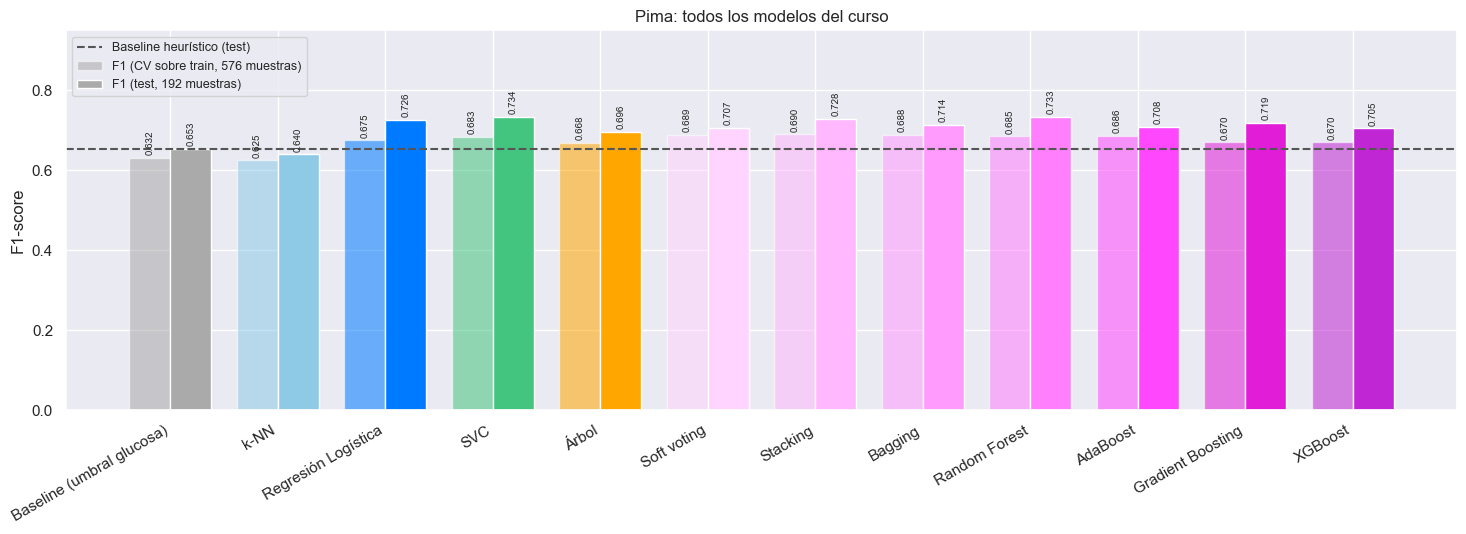

In [13]:
orden_m = ["Baseline (umbral glucosa)", "k-NN", "Regresión Logística",
           "SVC", "Árbol", "Soft voting",
           "Stacking", "Bagging", "Random Forest",
           "AdaBoost", "Gradient Boosting",
           "XGBoost"]
colores_m = ["#aaaaaa", "#8ecae6", "#007aff", "#44c57f", "#ffa600",
             "#ffd4fe", "#ffb7fe", "#ff9bfd", "#ff7ffd", "#ff48fd",
             "#e11dd8", "#c026d3"]

df_plot = df_final.loc[orden_m, ["F1 (CV train)", "F1 (test)"]]
x = np.arange(len(orden_m))
ancho = 0.38

fig, ax = plt.subplots(figsize=(15, 5.5))
b1 = ax.bar(x - ancho / 2, df_plot["F1 (CV train)"], ancho, color=colores_m,
            alpha=0.55, edgecolor="white",
            label="F1 (CV sobre train, 576 muestras)")
b2 = ax.bar(x + ancho / 2, df_plot["F1 (test)"], ancho, color=colores_m,
            alpha=1.0, edgecolor="white", label="F1 (test, 192 muestras)")
ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=7, rotation=90)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=7, rotation=90)

ax.axhline(df_final.loc["Baseline (umbral glucosa)", "F1 (test)"],
           color="#555555", linestyle="--", lw=1.5,
           label="Baseline heurístico (test)")
ax.set_xticks(x)
ax.set_xticklabels(orden_m, rotation=30, ha="right")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 0.95)
ax.set_title("Pima: todos los modelos del curso")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

Y las curvas ROC de los mejores representantes de cada familia:

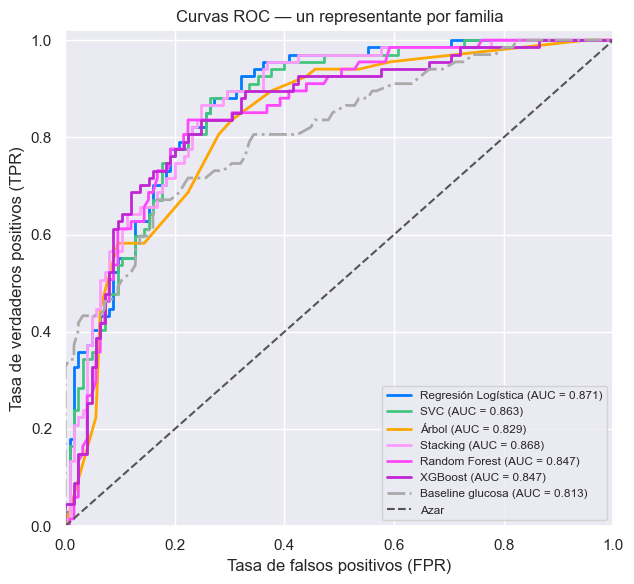

In [14]:
curvas = [
    ("Regresión Logística", logreg, "#007aff"),
    ("SVC", svc, "#44c57f"),
    ("Árbol", arbol_c4, "#ffa600"),
    ("Stacking", stacking, "#ff9bfd"),
    ("Random Forest", rf, "#ff48fd"),
    ("XGBoost", xgb_tuned, "#c026d3"),
]

fig, ax = plt.subplots(figsize=(6.5, 6))
for nombre, modelo, color in curvas:
    modelo.fit(X_train, y_train)
    proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{nombre} (AUC = {roc_auc_score(y_test, proba):.3f})")

# El baseline también tiene curva: usamos la glucosa como score continuo
fpr_b, tpr_b, _ = roc_curve(y_test, X_test["glucosa"])
ax.plot(fpr_b, tpr_b, lw=2, color="#aaaaaa", linestyle="-.",
        label=f"Baseline glucosa (AUC = "
              f"{roc_auc_score(y_test, X_test['glucosa']):.3f})")

ax.plot([0, 1], [0, 1], color="#555555", lw=1.5, linestyle="--", label="Azar")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Tasa de falsos positivos (FPR)")
ax.set_ylabel("Tasa de verdaderos positivos (TPR)")
ax.set_title("Curvas ROC — un representante por familia")
ax.legend(loc="lower right", fontsize=8.5)
plt.tight_layout()
plt.show()

### Observaciones finales

- **Los ensambles ocupan la parte alta de la tabla por F1 de validación cruzada**, pero
  el pelotón está muy apretado: entre el stacking, el soft voting, el bagging, el
  AdaBoost y el Random Forest hay menos de 0.005 de diferencia. Elegir un ganador entre
  ellos con estos datos no tiene sustento estadístico.
- **En testeo el ranking se reordena**, igual que nos pasó en la notebook 1. Con 192
  muestras, un puñado de pacientes alcanza para cambiar el podio. La lección se repite:
  **hay que mirar las dos columnas juntas** y desconfiar de las diferencias en la tercera
  cifra decimal.
- **XGBoost queda por debajo del Random Forest**, tanto por CV como en testeo. Junto con
  lo que vimos en Hitters y en el apéndice de California Housing, el panorama es
  consistente: el boosting moderno necesita volumen de datos. Con 576 muestras de
  entrenamiento, un Random Forest sin tuning es mejor negocio.
- **La ganancia total sobre la heurística es de ~0.06 en F1** (de 0.632 a
  0.690 por CV). Después de varias clases, una docena de modelos y varias búsquedas de
  hiper-parámetros, le ganamos a una única regla sobre la glucosa por un margen modesto.
  No es un fracaso: es la realidad de un dataset chico, ruidoso y con señal
  esencialmente contenida en una variable. Y es la razón por la que **el baseline nunca
  es opcional**: sin él, uno reporta un F1 de 0.73 y cree que hizo magia.

### Resumen de la clase

Cerramos con el mapa de lo que vimos en estas cuatro notebooks:

| Método | Cómo genera diversidad | Qué reduce | Cuándo conviene |
|---|---|---|---|
| **Voting / Stacking** | Modelos de familias distintas | Depende de la diversidad real | Ya hay modelos entrenados y son genuinamente distintos |
| **Bagging** | Remuestreo bootstrap | Varianza | Modelo base inestable (árboles profundos) |
| **Random Forest** | Bootstrap + subconjunto de atributos | Varianza (más que bagging) | Casi siempre: es el mejor punto de partida |
| **Boosting** | Secuencia sobre los errores | Sesgo | Hay muchos datos y se puede invertir en tuning |

Y las tres ideas que conviene llevarse, más allá de los algoritmos:

1. **La diversidad se mide, no se supone.** Antes de ensamblar, mirar si los modelos se
   equivocan en lugares distintos.
2. **El umbral, el `n_estimators` y el `learning_rate` son hiper-parámetros**, y se
   eligen por validación cruzada sobre el entrenamiento. Nunca mirando el testeo.
3. **Siempre hay que tener un baseline honesto.** Es lo único que convierte un número
   suelto en una medida de cuánto aportó realmente el modelo.